# Importing Modules

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Loading the master dataset with required columns

In [2]:
df=pd.read_csv("../datasets/olist_master_dataset.csv",usecols=['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date','order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 
       'product_id','shipping_limit_date', 'seller_id','price', 'freight_value', 'total_payment_value', 'payment_installments',
       'payments_method_count', 'primary_payment_type'])

In [3]:
df.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_payment_value,payment_installments,payments_method_count,primary_payment_type
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,3.0,2.0,credit_card
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46,1.0,1.0,boleto
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12,3.0,1.0,credit_card


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113314 entries, 0 to 113313
Data columns (total 18 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       113314 non-null  object 
 1   customer_id                    113314 non-null  object 
 2   order_status                   113314 non-null  object 
 3   order_purchase_timestamp       113314 non-null  object 
 4   order_approved_at              113314 non-null  object 
 5   order_delivered_carrier_date   112111 non-null  object 
 6   order_delivered_customer_date  110839 non-null  object 
 7   order_estimated_delivery_date  113314 non-null  object 
 8   order_item_id                  113314 non-null  int64  
 9   product_id                     113314 non-null  object 
 10  seller_id                      113314 non-null  object 
 11  shipping_limit_date            113314 non-null  object 
 12  price                         

In [5]:
date_cols=['order_purchase_timestamp','order_approved_at', 'order_delivered_carrier_date','order_delivered_customer_date', 
           'order_estimated_delivery_date','shipping_limit_date']
for col in date_cols:
    df[col]=pd.to_datetime(df[col],errors='coerce')

In [6]:
df['payment_installments']=pd.to_numeric(df['payment_installments'],errors='coerce').astype(int)
df['payments_method_count']=pd.to_numeric(df['payments_method_count'],errors='coerce').astype(int)

# Exploring the Data and Feature Engineering

In [7]:
df['year']=df['order_purchase_timestamp'].dt.year

In [8]:
year_sales=df.groupby('year')['total_payment_value'].sum().reset_index()
year_sales

,year,total_payment_value
0,2016,74720.60
1,2017,9229114.30
2,2018,11113007.64


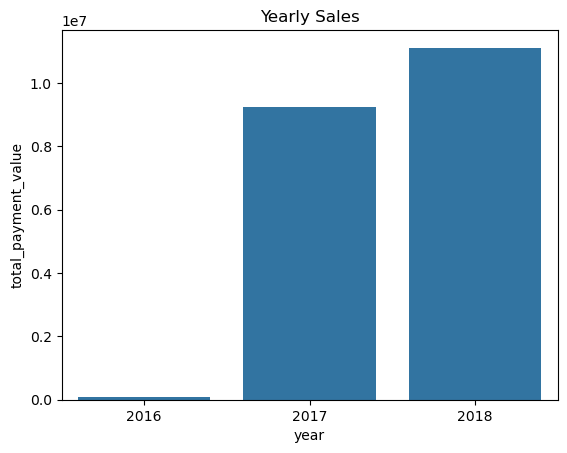

In [9]:
sns.barplot(x='year',y='total_payment_value',data=year_sales)
plt.title("Yearly Sales")
plt.show();

In [10]:
yearly_orders=df.groupby('year')['order_id'].count().reset_index()
yearly_orders

,year,order_id
0,2016,374
1,2017,51269
2,2018,61671


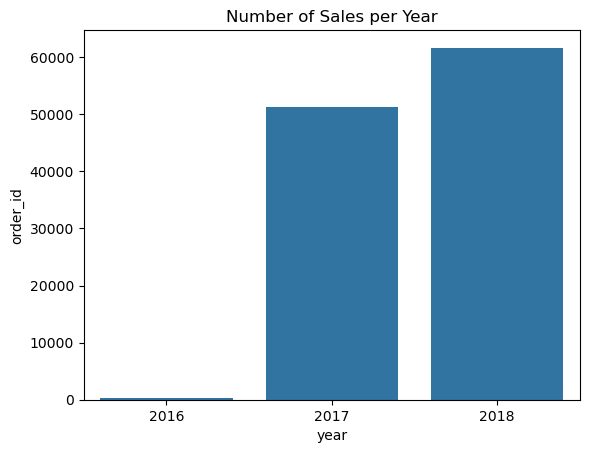

In [11]:
sns.barplot(x='year', y='order_id', data=yearly_orders)
plt.title('Number of Sales per Year')
plt.show()

In [12]:
df2=df[df['order_item_id']==1]

In [13]:
weekly_sales=df2.resample('W',on='order_purchase_timestamp').agg({'total_payment_value':'sum','order_id':'nunique'}).reset_index()

In [14]:
weekly_sales.rename(columns={'order_purchase_timestamp':'week','order_id':'num_of_order'},inplace=True)

In [15]:
weekly_sales.head()

,week,total_payment_value,num_of_order
0,2016-09-04,136.23,1
1,2016-09-11,75.06,1
2,2016-09-18,0.00,1
3,2016-09-25,0.00,0
4,2016-10-02,109.34,1


In [16]:
weekly_sales['sales_lag_1']=weekly_sales['total_payment_value'].shift(1)
weekly_sales['sales_lag_2']=weekly_sales['total_payment_value'].shift(2)
weekly_sales['sales_lag_3']=weekly_sales['total_payment_value'].shift(3)
weekly_sales['sales_lag_4']=weekly_sales['total_payment_value'].shift(4)

In [17]:
weekly_sales['rolling_mean_4']=weekly_sales['total_payment_value'].shift(1).rolling(window=4).mean()
weekly_sales['rolling_std_4']=weekly_sales['total_payment_value'].shift(1).rolling(window=4).std()

In [18]:
weekly_sales['year']=weekly_sales['week'].dt.year
weekly_sales['month']=weekly_sales['week'].dt.month
weekly_sales['week_of_year']=weekly_sales['week'].dt.isocalendar().week

In [19]:
weekly_sales.head()

,week,total_payment_value,num_of_order,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_4,rolling_mean_4,rolling_std_4,year,month,week_of_year
0,2016-09-04,136.23,1,NaN,NaN,NaN,NaN,NaN,NaN,2016,9,35
1,2016-09-11,75.06,1,136.23,NaN,NaN,NaN,NaN,NaN,2016,9,36
2,2016-09-18,0.00,1,75.06,136.23,NaN,NaN,NaN,NaN,2016,9,37
3,2016-09-25,0.00,0,0.00,75.06,136.23,NaN,NaN,NaN,2016,9,38
4,2016-10-02,109.34,1,0.00,0.00,75.06,136.23,52.8225,65.908397,2016,10,39


In [20]:
weekly_sales.dropna(inplace=True)

# Modeling the Sales Forecast model

In [21]:
train=weekly_sales[weekly_sales['year']<2018]
test=weekly_sales[weekly_sales['year']==2018]

In [22]:
train.columns

Index(['week', 'total_payment_value', 'num_of_order', 'sales_lag_1',
       'sales_lag_2', 'sales_lag_3', 'sales_lag_4', 'rolling_mean_4',
       'rolling_std_4', 'year', 'month', 'week_of_year'],
      dtype='object')

In [23]:
x_train=train[['num_of_order', 'sales_lag_1','sales_lag_2', 'sales_lag_3', 'sales_lag_4', 'rolling_mean_4','rolling_std_4',
              'year', 'month', 'week_of_year']]
y_train=train['total_payment_value']


x_test=test[['num_of_order', 'sales_lag_1','sales_lag_2', 'sales_lag_3', 'sales_lag_4', 'rolling_mean_4','rolling_std_4',
              'year', 'month', 'week_of_year']]
y_test=test['total_payment_value']

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,r2_score

In [25]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [26]:
y_pred=model.predict(x_test)
mean_absolute_error(y_test,y_pred)

12407.412917688056

In [27]:
r2_score(y_test,y_pred)

0.9532449266314766

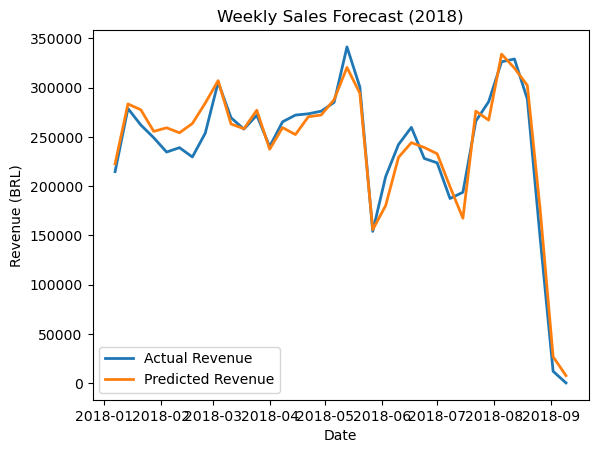

In [28]:
plt.plot(test['week'], y_test, label='Actual Revenue', linewidth=2)
plt.plot(test['week'], y_pred, label='Predicted Revenue', linewidth=2)
plt.title('Weekly Sales Forecast (2018)')
plt.xlabel('Date')
plt.ylabel('Revenue (BRL)')
plt.legend()
plt.show()

# Saving the Model

In [29]:
from joblib import dump
dump(model,'../backend/models/sales_forecast_model.joblib')

['../backend/models/sales_forecast_model.joblib']

In [30]:
from joblib import load
sales_model=load('../backend/models/sales_forecast_model.joblib')

In [31]:
sales_pred=sales_model.predict(x_test)

In [32]:
r2_score(y_test,sales_pred)

0.9532449266314766

In [33]:
x_test.head()

,num_of_order,sales_lag_1,sales_lag_2,sales_lag_3,sales_lag_4,rolling_mean_4,rolling_std_4,year,month,week_of_year
70,1372,119600.08,151486.26,219574.78,259949.87,187652.7475,63731.390624,2018,1,1
71,1771,214754.40,119600.08,151486.26,219574.78,176353.8800,48928.650339,2018,1,2
72,1736,278839.30,214754.40,119600.08,151486.26,191170.0100,70567.184902,2018,1,3
73,1583,262087.30,278839.30,214754.40,119600.08,218820.2700,71497.079776,2018,1,4
74,1596,249175.62,262087.30,278839.30,214754.40,251214.1550,27171.328504,2018,2,5


In [34]:
y_test.head()

70    214754.40
71    278839.30
72    262087.30
73    249175.62
74    234612.68
Name: total_payment_value, dtype: float64

In [36]:
sales_model.predict([[1372,119600.08,151486.26,219574.78,259949.87,187652.7475,63731.390624,2018,1,1]])

C:\Users\vighn\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([222641.16079705])